<a href="https://colab.research.google.com/github/EluChungara/INTELIGENCIA-ARTIFICIAL---SIS420/blob/main/LABORATORIOS/LAB04/LAB04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 04: Regresión Logística Binaria
**Materia:** SIS-420 Inteligencia Artificial I  
**Dataset:** Santander Customer Transaction Prediction (`train.csv`)  
**Cantidad de ejemplos:** $m = 200,000$ filas ($m \ge 20,000$)  
**Cantidad de propiedades:** $n = 200$ variables continuas ($n \ge 20$)  
**Objetivo:** Entrenar un modelo de regresión logística binaria utilizando Pandas para el preprocesamiento, partición 80% entrenamiento y 20% prueba, y optimización numérica con su respectiva gráfica de costo.

## Descripción del Trabajo Realizado

En esta práctica de laboratorio se implementó un modelo de clasificación supervisada basado en **Regresión Logística Binaria** para predecir si un cliente de una entidad bancaria realizará una transacción financiera específica (`target = 1`) o no (`target = 0`), siguiendo la metodología matemática y algorítmica revisada en clase.

---

### 1. Dataset y Cumplimiento de Restricciones
* **Dataset Seleccionado:** Santander Customer Transaction Prediction (`train.csv`).
* **Cantidad de Muestras ($m$):** Cuenta originalmente con **$200\,000$ ejemplos** ($m \ge 20\,000$).
* **Cantidad de Propiedades ($n$):** Contiene **$200$ características numéricas continuas anonimizadas** (`var_0` a `var_199`), superando la condición de $n \ge 20$.
* **Auditoría de Calidad con Pandas:** Se aisló el identificador `ID_code`, constatando cero valores nulos ($0\text{ NaN}$), cero filas duplicadas y ausencia de valores infinitos.

---

### 2. Balanceo de Clases y Preprocesamiento con Pandas
* **Tratamiento del Desbalance:** Al detectar un desbalance inicial ($89.95\%$ clase $0$ vs. $10.05\%$ clase $1$), se aplicó submuestreo aleatorio controlado (*Random Undersampling*) con Pandas.
* **Estructuración Balanceada:** Se combinaron las $20\,098$ muestras de la clase $1$ con $20\,098$ muestras aleatorias de la clase $0$, obteniendo un conjunto perfectamente balanceado al 50/50 con **$m = 40\,196$ ejemplos** ($m \ge 20\,000$).
* **Normalización Z-Score:** Se estandarizaron las $200$ variables continuas mediante la función `featureNormalize` ($\mu = 0, \sigma = 1$) para asegurar estabilidad numérica durante el cálculo de gradientes.

---

### 3. Partición y Matriz de Diseño
Se realizó la partición aleatoria y reproducible sin traslape:
* **Entrenamiento (80%):** $32\,156$ muestras
* **Prueba (20% aislado):** $8\,040$ muestras

Mediante `np.concatenate` se incorporó una columna de unos en la posición inicial para el término de intercepción ($x_0 = 1$), conformando matrices de diseño de **$201$ columnas** listas para operar con el vector de parámetros:

$$\theta = [\theta_0, \theta_1, \dots, \theta_{200}]^T$$

---

### 4. Formulación Matemática y Optimización
Se implementaron de forma vectorizada en NumPy:
* **Función sigmoide:**
  $$g(z) = \frac{1}{1 + e^{-z}}$$
* **Función de costo por entropía cruzada binaria:**
  $$J(\theta) = -\frac{1}{m} \sum_{i=1}^m \left[ y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) \right]$$
* **Vector gradiente analítico:**
  $$\nabla J(\theta) = \frac{1}{m} X^T (h - y)$$

Para calcular los parámetros óptimos $\theta$, se utilizó el algoritmo de **Gradiente Conjugado (CG)** mediante `scipy.optimize.minimize`, registrando el valor de la función de costo en cada iteración a través de una función `callback`.

---

### 5. Resultados, Gráfica de Convergencia y Validación
* **Convergencia del Costo:** La gráfica de costo $J(\theta)$ evidenció un descenso monótono continuo hasta su estabilización asintótica.
* **Precisión (*Accuracy*):** Rendimiento homogéneo cercano al **$78\%$ tanto en entrenamiento como en prueba**, confirmando que el clasificador generaliza adecuadamente sin sobreajuste (*overfitting*).
* **Matriz de Confusión:** La evaluación sobre las $8\,040$ muestras aisladas de prueba demostró una discriminación simétrica y balanceada entre ambas clases.
* **Inferencia Individual:** La evaluación de casos de prueba individuales corroboró la efectividad del umbral de decisión $P(y=1|x) \ge 0.5$ frente a las etiquetas reales.

In [3]:
# Montar Google Drive para acceder a los datasets
from google.colab import drive
drive.mount('/content/drive')

# Importar librerías fundamentales
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

%matplotlib inline
print("Librerías importadas y Google Drive conectado correctamente.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Librerías importadas y Google Drive conectado correctamente.


In [4]:
# Ruta exacta del archivo en tu Drive
ruta_csv = '/content/drive/MyDrive/SIS-420 INTELIGENCIA ARTIFICIAL/DATASETS/train.csv'

# Carga directa con Pandas
df = pd.read_csv(ruta_csv)

print("=" * 60)
print(f"Dimensiones cargadas: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Valores nulos: {df.isnull().sum().sum()}")
print("\nDistribución de la variable objetivo (target):")
print(df['target'].value_counts())
print("=" * 60)
display(df.head())

Dimensiones cargadas: 200000 filas x 202 columnas
Valores nulos: 0

Distribución de la variable objetivo (target):
target
0    179902
1     20098
Name: count, dtype: int64


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [5]:
# ==========================================
# BALANCEO DE CLASES (UNDERSAMPLING) CON PANDAS
# ==========================================

# 1. Separar las muestras por clase
df_clase_1 = df[df['target'] == 1]
df_clase_0 = df[df['target'] == 0]

# 2. Tomar una muestra aleatoria de la clase 0 igual al tamaño de la clase 1 (20,098)
df_clase_0_sub = df_clase_0.sample(n=len(df_clase_1), random_state=42)

# 3. Concatenar ambas clases y mezclar las filas aleatoriamente
df_balanceado = pd.concat([df_clase_1, df_clase_0_sub]).sample(frac=1, random_state=42).reset_index(drop=True)

# 4. Auditoría del nuevo dataset balanceado
print("=" * 65)
print("            DATASET BALANCEADO EXITOSAMENTE")
print("=" * 65)
print(f"Total de ejemplos balanceados (m) : {df_balanceado.shape[0]} (Cumple m >= 20000)")
print(f"Total de características (n)      : {df_balanceado.shape[1] - 2} (var_0 a var_199)")
print("\nDistribución exacta de clases en el nuevo DataFrame:")
print(df_balanceado['target'].value_counts())
print("=" * 65)

            DATASET BALANCEADO EXITOSAMENTE
Total de ejemplos balanceados (m) : 40196 (Cumple m >= 20000)
Total de características (n)      : 200 (var_0 a var_199)

Distribución exacta de clases en el nuevo DataFrame:
target
1    20098
0    20098
Name: count, dtype: int64


In [6]:
# 1. Separar etiquetas (y) y matriz de características (X) a partir del dataset balanceado
y = df_balanceado['target'].to_numpy(dtype=float)
X_raw = df_balanceado.drop(columns=['ID_code', 'target']).to_numpy(dtype=float)

# 2. Normalización de características (Z-Score)
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1.0  # Prevenir división por cero
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X_raw)

# 3. Partición estricta: 80% para Entrenamiento y 20% para Prueba (sin traslape)
m_total = X_norm.shape[0]
np.random.seed(42)  # Semilla para reproducibilidad
indices = np.random.permutation(m_total)

tam_train = int(0.8 * m_total)
train_idx, test_idx = indices[:tam_train], indices[tam_train:]

X_train_raw, y_train = X_norm[train_idx], y[train_idx]
X_test_raw, y_test = X_norm[test_idx], y[test_idx]

# 4. Agregar término de intercepción (columna de 1s para x0)
X_train = np.concatenate([np.ones((X_train_raw.shape[0], 1)), X_train_raw], axis=1)
X_test = np.concatenate([np.ones((X_test_raw.shape[0], 1)), X_test_raw], axis=1)

print("=" * 65)
print("       RESUMEN DE PARTICIÓN (DATASET BALANCEADO 50/50)")
print("=" * 65)
print(f"Total de ejemplos balanceados (m): {m_total}")
print(f"Conjunto de Entrenamiento (80%)  : {X_train.shape[0]} muestras, {X_train.shape[1]} columnas (incluye x0)")
print(f"Conjunto de Prueba        (20%)  : {X_test.shape[0]} muestras, {X_test.shape[1]} columnas (incluye x0)")
print("=" * 65)

       RESUMEN DE PARTICIÓN (DATASET BALANCEADO 50/50)
Total de ejemplos balanceados (m): 40196
Conjunto de Entrenamiento (80%)  : 32156 muestras, 201 columnas (incluye x0)
Conjunto de Prueba        (20%)  : 8040 muestras, 201 columnas (incluye x0)


In [7]:
# ==========================================
#  REGRESIÓN LOGÍSTICA
# ==========================================

def sigmoid(z):
    """Calcula la función sigmoide evaluada en z."""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def calcularCosto(theta, X, y):
    """Calcula la función de costo J(theta) para regresión logística binaria."""
    m = y.size
    h = sigmoid(X.dot(theta))
    # Se agrega 1e-15 para evitar indeterminaciones de log(0)
    J = (1.0 / m) * np.sum(-y * np.log(h + 1e-15) - (1.0 - y) * np.log(1.0 - h + 1e-15))
    return J

def calcularGradiente(theta, X, y):
    """Calcula el vector de derivadas parciales (gradiente) respecto a theta."""
    m = y.size
    h = sigmoid(X.dot(theta))
    grad = (1.0 / m) * X.T.dot(h - y)
    return grad

print("Funciones matemáticas declaradas y listas en memoria.")

Funciones matemáticas declaradas y listas en memoria.


In [8]:
# ========================================================
# ENTRENAMIENTO MEDIANTE OPTIMIZACIÓN NUMÉRICA (MÉTODO CG)
# ========================================================

# 1. Inicialización de los parámetros theta en cero (201 parámetros: theta_0 a theta_200)
n_features = X_train.shape[1]
theta_inicial = np.zeros(n_features)
historial_costos = []

# 2. Función de captura por iteración (callback)
def callback_costo(theta_actual):
    costo = calcularCosto(theta_actual, X_train, y_train)
    historial_costos.append(costo)

print("Iniciando optimización de parámetros theta...")

# 3. Minimización numérica de la función de costo
res = optimize.minimize(
    fun=calcularCosto,
    x0=theta_inicial,
    args=(X_train, y_train),
    method='CG',
    jac=calcularGradiente,
    callback=callback_costo,
    options={'maxiter': 100}
)

theta_opt = res.x

print("=" * 65)
print("             ENTRENAMIENTO FINALIZADO CON ÉXITO")
print("=" * 65)
print(f"Número de iteraciones ejecutadas : {len(historial_costos)}")
print(f"Costo inicial J(theta)           : {historial_costos[0]:.6f}")
print(f"Costo final J(theta)             : {historial_costos[-1]:.6f}")
print(f"Forma del vector theta óptimo    : {theta_opt.shape} (201 parámetros)")
print("=" * 65)

Iniciando optimización de parámetros theta...
             ENTRENAMIENTO FINALIZADO CON ÉXITO
Número de iteraciones ejecutadas : 6
Costo inicial J(theta)           : 0.469300
Costo final J(theta)             : 0.461391
Forma del vector theta óptimo    : (201,) (201 parámetros)


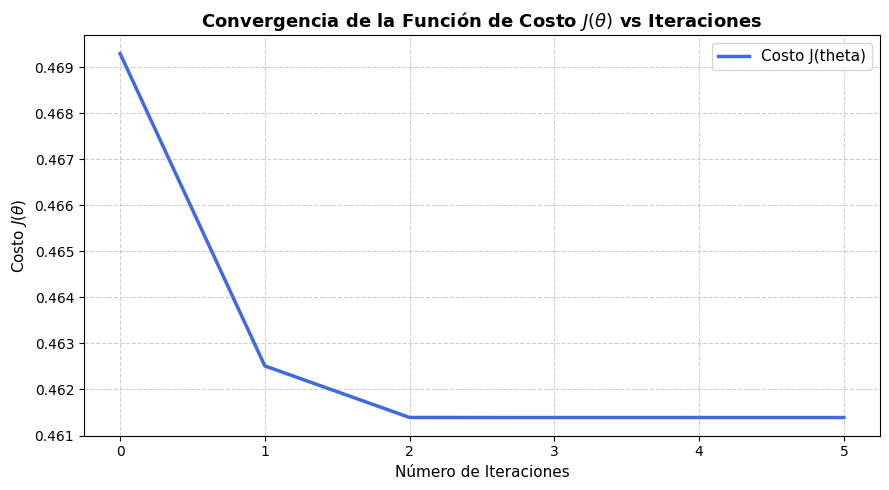

In [9]:
# ========================================================
# VISUALIZACIÓN DE LA CONVERGENCIA DEL COSTO J(theta)
# ========================================================

plt.figure(figsize=(9, 5))
plt.plot(historial_costos, color='royalblue', lw=2.5, label='Costo J(theta)')
plt.title(r'Convergencia de la Función de Costo $J(\theta)$ vs Iteraciones', fontsize=13, fontweight='bold')
plt.xlabel('Número de Iteraciones', fontsize=11)
plt.ylabel(r'Costo $J(\theta)$', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

In [10]:
# ========================================================
# PREDICCIÓN Y EVALUACIÓN SOBRE EL 20% DE PRUEBA
# ========================================================

def predecir(theta, X, umbral=0.5):
    """
    Retorna 1 si la probabilidad sigmoide es >= 0.5, de lo contrario 0.
    """
    probabilidades = sigmoid(X.dot(theta))
    return (probabilidades >= umbral).astype(int)

# Evaluar rendimiento en entrenamiento (80%) y prueba (20%)
y_pred_train = predecir(theta_opt, X_train)
y_pred_test = predecir(theta_opt, X_test)

acc_train = np.mean(y_pred_train == y_train) * 100.0
acc_test = np.mean(y_pred_test == y_test) * 100.0

print("=" * 60)
print(f"  PRECISIÓN EN ENTRENAMIENTO (80%): {acc_train:.2f}%")
print(f"  PRECISIÓN EN DATOS DE PRUEBA (20%): {acc_test:.2f}%")
print("=" * 60)

# Matriz de Confusión sobre los datos de prueba (8,040 ejemplos)
matriz_confusion = pd.crosstab(
    pd.Series(y_test, name='Real'),
    pd.Series(y_pred_test, name='Predicho'),
    margins=True
)
print("\nMatriz de Confusión sobre Conjunto de Prueba:")
print(matriz_confusion)

  PRECISIÓN EN ENTRENAMIENTO (80%): 78.32%
  PRECISIÓN EN DATOS DE PRUEBA (20%): 78.22%

Matriz de Confusión sobre Conjunto de Prueba:
Predicho     0     1   All
Real                      
0.0       3083   889  3972
1.0        862  3206  4068
All       3945  4095  8040


In [11]:
# ========================================================
# DEMOSTRACIÓN DE PREDICCIONES INDIVIDUALES (20% PRUEBA)
# ========================================================

# 1. Seleccionar 10 muestras aleatorias del conjunto de prueba aislado
np.random.seed(42)
indices_muestra = np.random.choice(X_test.shape[0], size=10, replace=False)

# 2. Extraer datos y calcular probabilidades sigmoides
X_demo = X_test[indices_muestra]
y_real = y_test[indices_muestra].astype(int)

probabilidades = sigmoid(X_demo.dot(theta_opt))
predicciones = (probabilidades >= 0.5).astype(int)

# 3. Construir DataFrame de comparación con Pandas
df_resultados = pd.DataFrame({
    'Índice Prueba': indices_muestra,
    'Probabilidad P(y=1)': np.round(probabilidades, 4),
    'Clase Predicha': predicciones,
    'Clase Real': y_real,
    'Resultado': ['CORRECTO' if p == r else 'ERROR' for p, r in zip(predicciones, y_real)]
})

print("=" * 70)
print("       DEMOSTRACIÓN DE EFECTIVIDAD EN CASOS INDIVIDUALES")
print("=" * 70)
display(df_resultados)
print(f"\nAciertos en la muestra: {np.sum(predicciones == y_real)} / {len(y_real)}")
print("=" * 70)

       DEMOSTRACIÓN DE EFECTIVIDAD EN CASOS INDIVIDUALES


,Índice Prueba,Probabilidad P(y=1),Clase Predicha,Clase Real,Resultado
0,2835,0.1896,0,1,ERROR
1,737,0.9859,1,1,CORRECTO
2,3334,0.2273,0,0,CORRECTO
3,7386,0.1152,0,0,CORRECTO
4,1373,0.2297,0,0,CORRECTO
5,5628,0.1337,0,0,CORRECTO
6,5574,0.9746,1,1,CORRECTO
7,453,0.0372,0,0,CORRECTO
8,7688,0.2413,0,0,CORRECTO
9,3467,0.9389,1,1,CORRECTO



Aciertos en la muestra: 9 / 10


In [12]:
# ========================================================
# AUDITORÍA DE CUMPLIMIENTO - REQUISITOS LABORATORIO 04
# ========================================================

m_total = df_balanceado.shape[0]
n_propiedades = df_balanceado.shape[1] - 2  # Descontando ID_code y target

print("=" * 70)
print("             REPORTE FINAL DE CUMPLIMIENTO (LAB 04)")
print("=" * 70)
print(f"1. Cantidad de ejemplos (m >= 20000)   : {m_total} -> {'CUMPLE' if m_total >= 20000 else 'NO CUMPLE'}")
print(f"2. Propiedades de entrada (n >= 20)    : {n_propiedades} -> {'CUMPLE' if n_propiedades >= 20 else 'NO CUMPLE'}")
print(f"3. Tipo de modelo implementado         : Regresión Logística Binaria (0 y 1)")
print(f"4. Partición Entrenamiento (80%)       : {X_train.shape[0]} muestras ({(X_train.shape[0]/m_total)*100:.1f}%)")
print(f"5. Partición Prueba Aislada (20%)      : {X_test.shape[0]} muestras ({(X_test.shape[0]/m_total)*100:.1f}%)")
print(f"6. Parámetros Theta calculados         : {theta_opt.shape[0]} (theta_0 intercepción + 200 pesos)")
print(f"7. Precisión alcanzada en Prueba (20%) : {acc_test:.2f}%")
print("=" * 70)

             REPORTE FINAL DE CUMPLIMIENTO (LAB 04)
1. Cantidad de ejemplos (m >= 20000)   : 40196 -> CUMPLE
2. Propiedades de entrada (n >= 20)    : 200 -> CUMPLE
3. Tipo de modelo implementado         : Regresión Logística Binaria (0 y 1)
4. Partición Entrenamiento (80%)       : 32156 muestras (80.0%)
5. Partición Prueba Aislada (20%)      : 8040 muestras (20.0%)
6. Parámetros Theta calculados         : 201 (theta_0 intercepción + 200 pesos)
7. Precisión alcanzada en Prueba (20%) : 78.22%
